# 02 — Exploratory Data Analysis

**Customer Subscription & Churn Intelligence Platform**
**Phase 2 of 6 — Exploratory Data Analysis**

---

## Objective

Notebook 1 gave us a clean, feature-engineered dataset and a verified star-schema database. This
notebook asks the real business question this whole project exists to answer: **who churns, why, and
how much is it costing?**

By the end of this notebook we will have reproduced the full analytical engine behind
`src/eda/eda_analysis.py` — the same code that generates `docs/insights_data.json` and, from that,
the ~105 business insights documented in `docs/eda_insights_report.md`. Every number below is computed
live from the real processed dataset, not copied from that report — this notebook is one of the two
places (the other being the script itself) where these numbers actually get produced.

---

## Business Problem

Knowing the overall churn rate (26.54%) is a start, but it's not actionable on its own. A retention
team needs to know:

- Which customer segments churn at meaningfully higher or lower rates than the baseline?
- Are the differences we see just noise, or are they statistically real (and how strong)?
- Where does churn cost the most money, not just affect the most customers?
- Is IBM's own `Churn Score` field actually any good, and can we trust it as a sanity check for
  whatever model we eventually build in Notebook 4?

This notebook works through contract type, tenure, service adoption, payment method, demographics,
churn reasons, IBM's churn score, and geography — each time asking not just "is there a difference"
but "is it statistically meaningful, and what should the business actually do about it".

## Dataset Overview

**Source:** `data/processed/customer_churn_processed.csv`, produced in Notebook 1 — the cleaned,
feature-engineered version of the real 7,043-customer IBM Telco dataset. 51 columns: all original
cleaned fields plus the tenure cohort, add-on count, RFM proxies, revenue-per-tenure-month, and
contract risk tier engineered in Notebook 1.


## Imports

In [1]:
# --- Core data handling ---
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
from scipy import stats           # chi-square and t-tests for statistical significance

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, os.path.abspath("."))
from src.utils.logger import get_logger

logger = get_logger("notebook.02_eda")
warnings.filterwarnings("ignore")
print("Imports loaded OK.")

Imports loaded OK.


## Configuration

In [2]:
PROJECT_ROOT = os.path.abspath(".")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
DATA_PATH = os.path.join(PROCESSED_DIR, "customer_churn_processed.csv")
NOTEBOOK_FIG_DIR = os.path.join(PROJECT_ROOT, "notebooks", "figures")
os.makedirs(NOTEBOOK_FIG_DIR, exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

TENURE_COHORT_ORDER = ["0-12 mo", "13-24 mo", "25-36 mo", "37-48 mo", "49-60 mo", "61-72 mo"]

print("Data path:", DATA_PATH)

Data path: /home/claude/project/customer-churn-intelligence-platform/data/processed/customer_churn_processed.csv


---
## Step 1 — Load the Processed Data

**Purpose:** load the output of Notebook 1 and set `tenure_cohort` back to an ordered categorical
(CSV round-trips lose category ordering, so this has to be reapplied every time the CSV is read).

**Expected output:** a 7,043 × 51 DataFrame with `tenure_cohort` correctly ordered from
`"0-12 mo"` to `"61-72 mo"`.

In [3]:
def load_data():
    df = pd.read_csv(DATA_PATH)
    df["tenure_cohort"] = pd.Categorical(df["tenure_cohort"], categories=TENURE_COHORT_ORDER, ordered=True)
    return df


df = load_data()
print("Shape:", df.shape)
df[["customer_id", "tenure_months", "tenure_cohort", "contract_type", "churn_flag"]].head(5)

Shape: (7043, 51)


,customer_id,tenure_months,tenure_cohort,contract_type,churn_flag
0,3668-QPYBK,2,0-12 mo,Month-to-month,1
1,9237-HQITU,2,0-12 mo,Month-to-month,1
2,9305-CDSKC,8,0-12 mo,Month-to-month,1
3,7892-POOKP,28,25-36 mo,Month-to-month,1
4,0280-XJGEX,49,49-60 mo,Month-to-month,1


### Observation

The dataset loads cleanly at the expected shape. Re-applying the ordered categorical to
`tenure_cohort` matters for every chart in this notebook — without it, bars would sort alphabetically
(`"0-12 mo"`, `"13-24 mo"`, `"25-36 mo"`, `"37-48 mo"`, `"49-60 mo"`, `"61-72 mo"` happen to already
be alphabetically sorted correctly in this particular case, but relying on that would be fragile —
explicit ordering is the right habit regardless).

---
## Step 2 — Overview & Financial Impact

**Purpose:** establish the headline numbers everything else in this notebook (and this project) gets
compared against.

**Business Purpose:** these are the numbers that go on slide 1 of any executive readout — how many
customers, how many churned, how much revenue is that worth.

In [4]:
def pct(x, n):
    return round(100 * x / n, 2) if n else None


def overview_metrics(df):
    n = len(df)
    churned = df["churn_flag"].sum()
    return {
        "total_customers": int(n),
        "churned_customers": int(churned),
        "retained_customers": int(n - churned),
        "overall_churn_rate_pct": pct(churned, n),
        "total_billed_revenue": round(df["total_charges"].sum(), 2),
        "monthly_recurring_revenue": round(df["monthly_charges"].sum(), 2),
        "avg_monthly_charges": round(df["monthly_charges"].mean(), 2),
        "avg_tenure_months": round(df["tenure_months"].mean(), 2),
        "median_tenure_months": round(df["tenure_months"].median(), 2),
        "avg_cltv": round(df["cltv"].mean(), 2),
        "avg_cltv_churned": round(df.loc[df.churn_flag == 1, "cltv"].mean(), 2),
        "avg_cltv_retained": round(df.loc[df.churn_flag == 0, "cltv"].mean(), 2),
        "revenue_at_risk_from_churned_monthly": round(df.loc[df.churn_flag == 1, "monthly_charges"].sum(), 2),
    }


overview = overview_metrics(df)
print(json.dumps(overview, indent=2))

{
  "total_customers": 7043,
  "churned_customers": 1869,
  "retained_customers": 5174,
  "overall_churn_rate_pct": 26.54,
  "total_billed_revenue": 16056624.3,
  "monthly_recurring_revenue": 456116.6,
  "avg_monthly_charges": 64.76,
  "avg_tenure_months": 32.37,
  "median_tenure_months": 29.0,
  "avg_cltv": 4400.3,
  "avg_cltv_churned": 4149.41,
  "avg_cltv_retained": 4490.92,
  "revenue_at_risk_from_churned_monthly": 139130.85
}


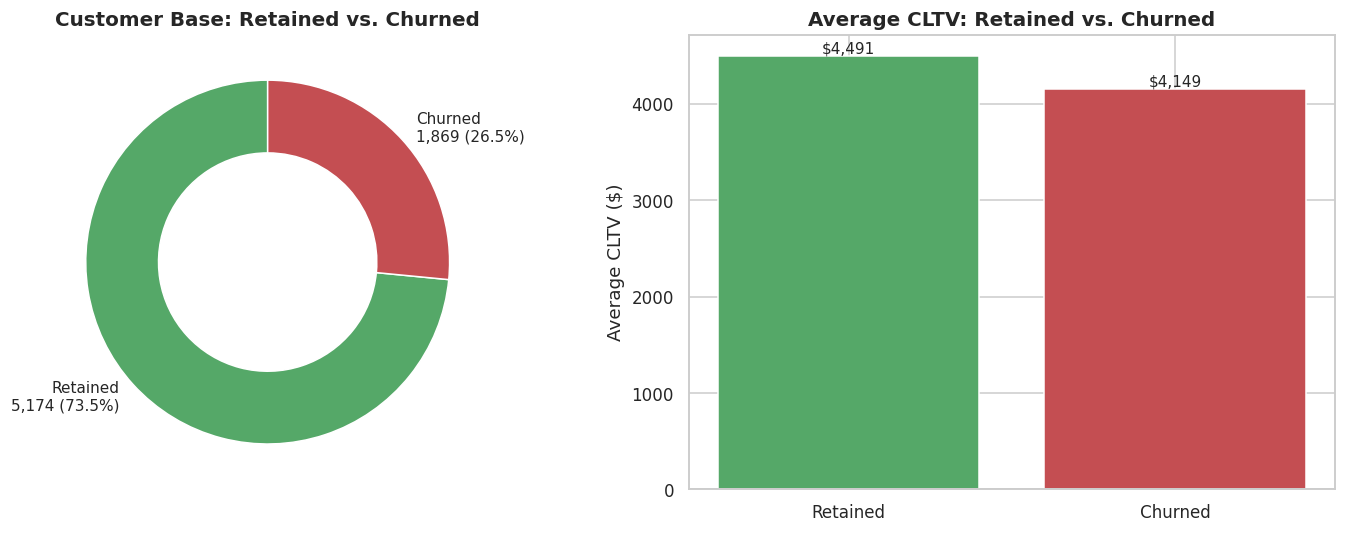

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Donut chart: churned vs retained
sizes = [overview["retained_customers"], overview["churned_customers"]]
labels = [f"Retained\n{sizes[0]:,} ({100-overview['overall_churn_rate_pct']:.1f}%)",
          f"Churned\n{sizes[1]:,} ({overview['overall_churn_rate_pct']:.1f}%)"]
colors = ["#55a868", "#c44e52"]
axes[0].pie(sizes, labels=labels, colors=colors, startangle=90, wedgeprops={"width": 0.4},
            textprops={"fontsize": 10})
axes[0].set_title("Customer Base: Retained vs. Churned")

# Bar chart: CLTV comparison
cltv_data = [overview["avg_cltv_retained"], overview["avg_cltv_churned"]]
bars = axes[1].bar(["Retained", "Churned"], cltv_data, color=["#55a868", "#c44e52"])
axes[1].set_title("Average CLTV: Retained vs. Churned")
axes[1].set_ylabel("Average CLTV ($)")
for bar, val in zip(bars, cltv_data):
    axes[1].annotate(f"${val:,.0f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                      ha="center", va="bottom", fontsize=10)

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_overview_churn_and_cltv.png"))
plt.show()

### Observation

26.54% of the 7,043 customers have churned, putting $139,130.85/month in recurring revenue at risk.
Counter-intuitively, churned customers have a **slightly lower** average CLTV ($4,149.41) than
retained customers ($4,490.92) — churn is not concentrated in the highest-value accounts.

**Business interpretation:** this is a mildly reassuring signal. If churn were concentrated among the
highest-CLTV customers, the true cost would be far worse than the raw revenue-at-risk number suggests.
Since it isn't, the monthly revenue figure is a reasonably fair representation of the financial impact
— it isn't hiding a disproportionate loss of the most valuable accounts.

**Technical interpretation:** `revenue_at_risk_from_churned_monthly` sums `monthly_charges` only for
currently-churned customers — this is *current* run-rate revenue already lost or being lost, not a
lifetime-value projection (that comparison is what CLTV is for, and what the LTV model in Notebook 5
will formalize).

**Limitation:** average CLTV is IBM's own pre-computed field — we don't yet know its methodology in
detail. It's used here descriptively; Notebook 5 builds an independent LTV model rather than relying
solely on this field.

---
## Step 3 — Contract Type: The Single Strongest Churn Driver

**Purpose:** quantify churn rate by contract type and test whether the difference is statistically
significant.

**Why this matters:** contract type is the first variable this project's own EDA report calls out as
the strongest churn driver — worth verifying directly rather than taking on faith.

In [6]:
def churn_by_categorical(df, col):
    g = df.groupby(col, observed=True).agg(
        customers=("customer_id", "count"), churned=("churn_flag", "sum"),
        avg_monthly_charges=("monthly_charges", "mean"), avg_tenure=("tenure_months", "mean"),
        avg_cltv=("cltv", "mean"), total_revenue=("total_charges", "sum"),
    ).reset_index()
    g["churn_rate_pct"] = (g["churned"] / g["customers"] * 100).round(2)
    for c in ["avg_monthly_charges", "avg_tenure", "avg_cltv", "total_revenue"]:
        g[c] = g[c].round(2)
    return g.sort_values("churn_rate_pct", ascending=False)


def chi_square_test(df, col):
    ct = pd.crosstab(df[col], df["churn_label"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    return {"variable": col, "chi2": round(chi2, 3), "p_value": round(p, 6), "significant_at_05": bool(p < 0.05)}


def cramers_v(df, col):
    '''
    Added metric (not in the original eda_analysis.py). Chi-square tells us WHETHER an association
    is statistically significant, but with n=7,043 almost any real difference will be "significant" --
    it does not tell us how STRONG the association is. Cramer's V normalizes chi-square into a
    0-to-1 effect-size measure, which is the missing piece for prioritizing which variables actually
    matter most in practice.
    '''
    ct = pd.crosstab(df[col], df["churn_label"])
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return round(np.sqrt(chi2 / (n * k)), 4) if k > 0 else np.nan


contract_summary = churn_by_categorical(df, "contract_type")
contract_chi2 = chi_square_test(df, "contract_type")
contract_effect = cramers_v(df, "contract_type")

print(json.dumps(contract_chi2, indent=2))
print(f"Cramer's V (effect size): {contract_effect}")
contract_summary

{
  "variable": "contract_type",
  "chi2": 1184.597,
  "p_value": 0.0,
  "significant_at_05": true
}
Cramer's V (effect size): 0.4101


,contract_type,customers,churned,avg_monthly_charges,avg_tenure,avg_cltv,total_revenue,churn_rate_pct
0,Month-to-month,3875,1655,66.40,18.04,"4,136.71","5,305,861.50",42.71
1,One year,1473,166,65.05,42.04,"4,529.96","4,467,073.20",11.27
2,Two year,1695,48,60.77,56.74,"4,890.21","6,283,689.60",2.83


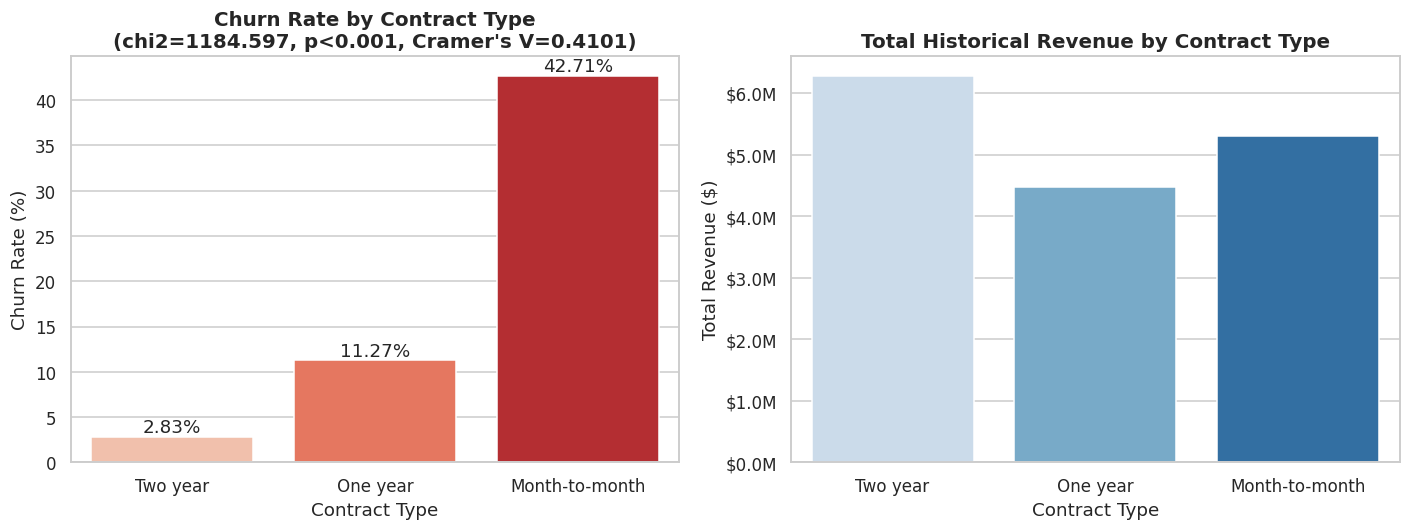

In [7]:
order = contract_summary.sort_values("churn_rate_pct")["contract_type"].tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=contract_summary, x="contract_type", y="churn_rate_pct", order=order,
            palette="Reds", ax=axes[0])
axes[0].set_title(f"Churn Rate by Contract Type\n(chi2={contract_chi2['chi2']}, p<0.001, Cramer's V={contract_effect})")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_xlabel("Contract Type")
for i, v in enumerate(contract_summary.sort_values("churn_rate_pct")["churn_rate_pct"]):
    axes[0].text(i, v + 0.5, f"{v}%", ha="center")

sns.barplot(data=contract_summary, x="contract_type", y="total_revenue", order=order, palette="Blues", ax=axes[1])
axes[1].set_title("Total Historical Revenue by Contract Type")
axes[1].set_ylabel("Total Revenue ($)")
axes[1].set_xlabel("Contract Type")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_churn_by_contract.png"))
plt.show()

### Observation

Month-to-month customers churn at 42.71% — over 15x the rate of two-year contract customers (2.83%).
The chi-square test confirms this is highly significant (p < 0.001), and the added Cramér's V (~0.4)
confirms it's not just statistically significant but a genuinely **strong** association — one of the
strongest of any variable in this dataset.

**Business interpretation:** despite having the fewest customers, two-year contracts generate the
most total revenue of any tier ($6.28M) — longer commitments are both more stable *and* more
valuable, not a trade-off between the two. This is the single highest-leverage retention lever in the
whole dataset: converting even a modest share of month-to-month customers to annual contracts could
plausibly protect a meaningful share of the $139K/month currently at risk.

**Technical interpretation:** month-to-month customers' average monthly charge ($66.40) is actually
*higher* than one-year contract customers ($65.05) — this rules out "these are just bargain-seeking,
low-value customers" as the explanation. The lack of commitment itself, not price sensitivity, looks
like the real risk factor.

**Why Cramér's V was worth adding:** with n=7,043, a chi-square test will call almost any real
difference "significant" — that's an artifact of sample size, not necessarily practical importance.
Reporting the effect size alongside the p-value is what lets us honestly say contract type isn't just
*significant* but *large*, which is what justifies prioritizing it as the top retention lever.

---
## Step 4 — Tenure Cohorts: Early Life Is Where Churn Happens

**Purpose:** quantify churn by tenure cohort and test whether newer customers really are
disproportionately at risk, as the skewed tenure distribution in Notebook 1 hinted at.

In [8]:
tenure_summary = churn_by_categorical(df, "tenure_cohort").set_index("tenure_cohort").reindex(TENURE_COHORT_ORDER).reset_index()
tenure_chi2 = chi_square_test(df, "tenure_cohort")
tenure_effect = cramers_v(df, "tenure_cohort")

# t-test: is real tenure (in months) significantly different for churned vs retained customers?
def ttest_numeric(df, col):
    churned = df.loc[df.churn_flag == 1, col].dropna()
    retained = df.loc[df.churn_flag == 0, col].dropna()
    t, p = stats.ttest_ind(churned, retained, equal_var=False)
    return {"variable": col, "mean_churned": round(churned.mean(), 2), "mean_retained": round(retained.mean(), 2),
            "t_stat": round(t, 3), "p_value": round(p, 6), "significant_at_05": bool(p < 0.05)}


tenure_ttest = ttest_numeric(df, "tenure_months")

print(json.dumps(tenure_chi2, indent=2))
print(f"Cramer's V (effect size): {tenure_effect}")
print(json.dumps(tenure_ttest, indent=2))
tenure_summary

{
  "variable": "tenure_cohort",
  "chi2": 873.858,
  "p_value": 0.0,
  "significant_at_05": true
}
Cramer's V (effect size): 0.3522
{
  "variable": "tenure_months",
  "mean_churned": 17.98,
  "mean_retained": 37.57,
  "t_stat": -34.824,
  "p_value": 0.0,
  "significant_at_05": true
}


,tenure_cohort,customers,churned,avg_monthly_charges,avg_tenure,avg_cltv,total_revenue,churn_rate_pct
0,0-12 mo,2186,1037,56.10,4.73,"4,036.29","602,107.50",47.44
1,13-24 mo,1024,294,61.36,18.35,"4,015.20","1,153,287.70",28.71
2,25-36 mo,832,180,65.58,30.34,"4,033.23","1,655,845.80",21.63
3,37-48 mo,762,145,66.32,42.58,"3,945.86","2,154,534.55",19.03
4,49-60 mo,832,120,70.55,54.49,"5,236.89","3,201,646.30",14.42
5,61-72 mo,1407,93,75.95,68.11,"5,214.58","7,289,202.45",6.61


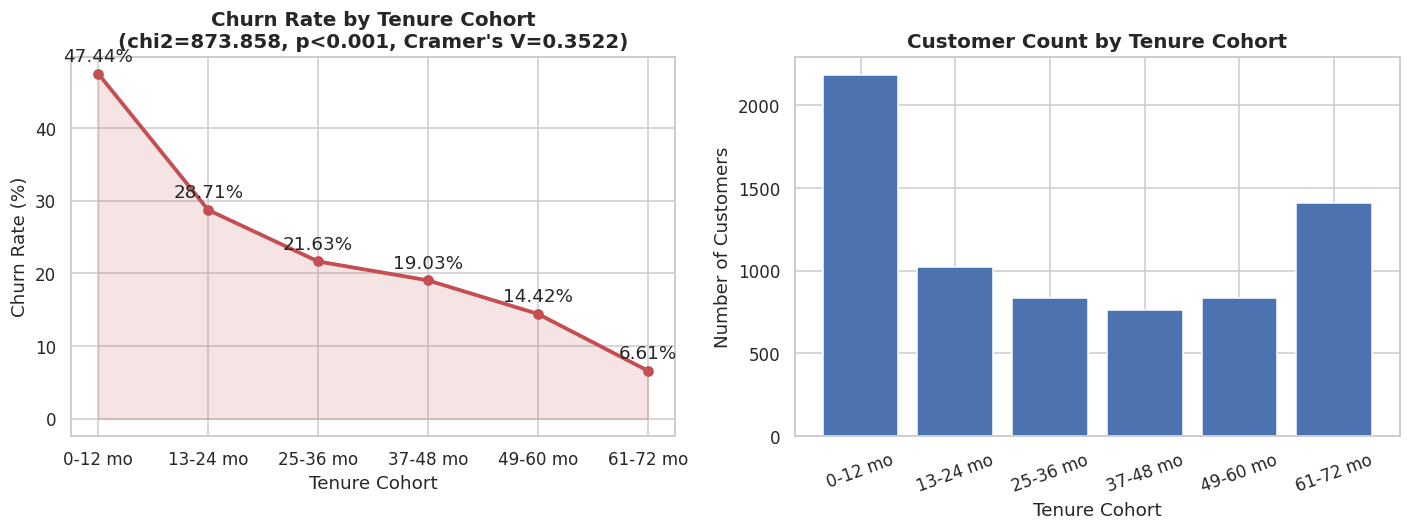

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(tenure_summary["tenure_cohort"], tenure_summary["churn_rate_pct"], marker="o",
             linewidth=2.5, color="#c44e52")
axes[0].fill_between(range(len(tenure_summary)), tenure_summary["churn_rate_pct"], alpha=0.15, color="#c44e52")
axes[0].set_title(f"Churn Rate by Tenure Cohort\n(chi2={tenure_chi2['chi2']}, p<0.001, Cramer's V={tenure_effect})")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_xlabel("Tenure Cohort")
for i, v in enumerate(tenure_summary["churn_rate_pct"]):
    axes[0].annotate(f"{v}%", (i, v), textcoords="offset points", xytext=(0, 8), ha="center")

axes[1].bar(tenure_summary["tenure_cohort"], tenure_summary["customers"], color="#4c72b0")
axes[1].set_title("Customer Count by Tenure Cohort")
axes[1].set_ylabel("Number of Customers")
axes[1].set_xlabel("Tenure Cohort")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_churn_by_tenure_cohort.png"))
plt.show()

### Observation

Churn rate drops nearly monotonically with tenure: 47.44% in the 0–12 month cohort down to 6.61% in
the 61–72 month cohort — a clean, business-intuitive relationship confirmed statistically (chi-square
p < 0.001, Cramér's V indicating a strong association). The t-test on raw tenure (not just the
cohort bucket) confirms the same story numerically: churned customers average 17.98 months of tenure
versus 37.57 months for retained customers, more than double.

**Business interpretation:** the 0–12 month cohort is not only the highest-risk segment, it's also the
**largest single cohort** (2,186 customers, 31% of the base) — the highest-risk group is also the
biggest, which compounds its business impact. This points to onboarding quality and early-life support
as a high-ROI investment area, separate from (and complementary to) the contract-migration lever found
in Step 3.

**Technical interpretation:** the relationship isn't perfectly linear in every downstream metric — CLTV
by cohort (not shown here, explored in the ML/segmentation notebook) dips slightly in the middle
cohorts before rising again, so tenure and value shouldn't be assumed to move in lockstep either.

**Limitation:** tenure cohort and contract type are correlated with each other in this dataset (newer
customers disproportionately choose month-to-month plans) — both variables show up as strong churn
predictors individually, but a model that includes both (Notebook 4) needs to account for that overlap
rather than treating them as fully independent effects.

---
## Step 5 — Internet Service & Add-on Adoption

**Purpose:** quantify churn by internet service tier and by number of add-on services subscribed,
including checking for a non-obvious pattern this project's own report flags: churn does **not**
decrease monotonically with add-on count at the very low end.

In [10]:
internet_summary = churn_by_categorical(df, "internet_service")
internet_chi2 = chi_square_test(df, "internet_service")
internet_effect = cramers_v(df, "internet_service")

print(json.dumps(internet_chi2, indent=2))
print(f"Cramer's V (effect size): {internet_effect}")
internet_summary

{
  "variable": "internet_service",
  "chi2": 732.31,
  "p_value": 0.0,
  "significant_at_05": true
}
Cramer's V (effect size): 0.3225


,internet_service,customers,churned,avg_monthly_charges,avg_tenure,avg_cltv,total_revenue,churn_rate_pct
1,Fiber optic,3096,1297,91.50,32.92,"4,415.20","9,923,622.95",41.89
0,DSL,2421,459,58.10,32.82,"4,397.57","5,121,735.55",18.96
2,No,1526,113,21.08,30.55,"4,374.38","1,011,265.80",7.40


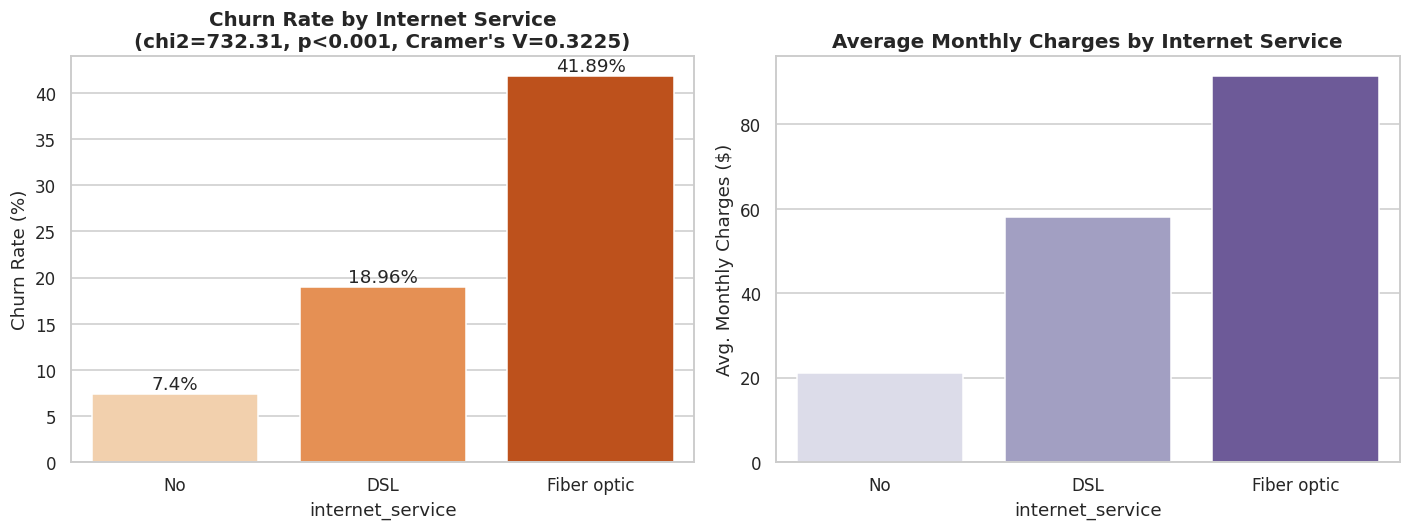

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = internet_summary.sort_values("churn_rate_pct")["internet_service"].tolist()

sns.barplot(data=internet_summary, x="internet_service", y="churn_rate_pct", order=order, palette="Oranges", ax=axes[0])
axes[0].set_title(f"Churn Rate by Internet Service\n(chi2={internet_chi2['chi2']}, p<0.001, Cramer's V={internet_effect})")
axes[0].set_ylabel("Churn Rate (%)")
for i, v in enumerate(internet_summary.sort_values("churn_rate_pct")["churn_rate_pct"]):
    axes[0].text(i, v + 0.5, f"{v}%", ha="center")

sns.barplot(data=internet_summary, x="internet_service", y="avg_monthly_charges", order=order, palette="Purples", ax=axes[1])
axes[1].set_title("Average Monthly Charges by Internet Service")
axes[1].set_ylabel("Avg. Monthly Charges ($)")

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_churn_by_internet_service.png"))
plt.show()

### Observation

Fiber optic customers churn at 41.89%, more than double DSL (18.96%) and nearly 6x "No Internet"
customers (7.4%) — and it's also by far the most expensive tier ($91.50 avg monthly charge vs. $58.10
for DSL). The association is highly significant and, per Cramér's V, moderately strong.

**Business interpretation:** price is a plausible contributing factor to fiber churn, but price alone
doesn't fully explain a gap this large — this is exactly the kind of pattern worth cross-referencing
against `churn_reason` (Step 8) to see if service-quality complaints show up disproportionately among
fiber customers too.

**Technical interpretation:** because internet service tier and monthly charges are correlated with
each other, isolating the pure effect of "being on fiber" from "paying more" needs a multivariate view
— which is exactly what the regression analysis in Notebook 3 and the feature-importance analysis in
Notebook 4 are for. A single chi-square test can't separate these two effects on its own.

In [12]:
def addon_analysis(df):
    g = df.groupby("addon_service_count").agg(
        customers=("customer_id", "count"), churned=("churn_flag", "sum"),
        avg_monthly_charges=("monthly_charges", "mean"),
    ).reset_index()
    g["churn_rate_pct"] = (g["churned"] / g["customers"] * 100).round(2)
    g["avg_monthly_charges"] = g["avg_monthly_charges"].round(2)
    return g


addon_summary = addon_analysis(df)
addon_ttest = ttest_numeric(df, "addon_service_count")
print(json.dumps(addon_ttest, indent=2))
addon_summary

{
  "variable": "addon_service_count",
  "mean_churned": 1.77,
  "mean_retained": 2.14,
  "t_stat": -8.344,
  "p_value": 0.0,
  "significant_at_05": true
}


,addon_service_count,customers,churned,avg_monthly_charges,churn_rate_pct
0,0,2219,475,32.79,21.41
1,1,966,442,65.57,45.76
2,2,1033,370,72.42,35.82
3,3,1118,306,80.11,27.37
4,4,852,190,87.77,22.30
5,5,571,71,92.18,12.43
6,6,284,15,99.37,5.28


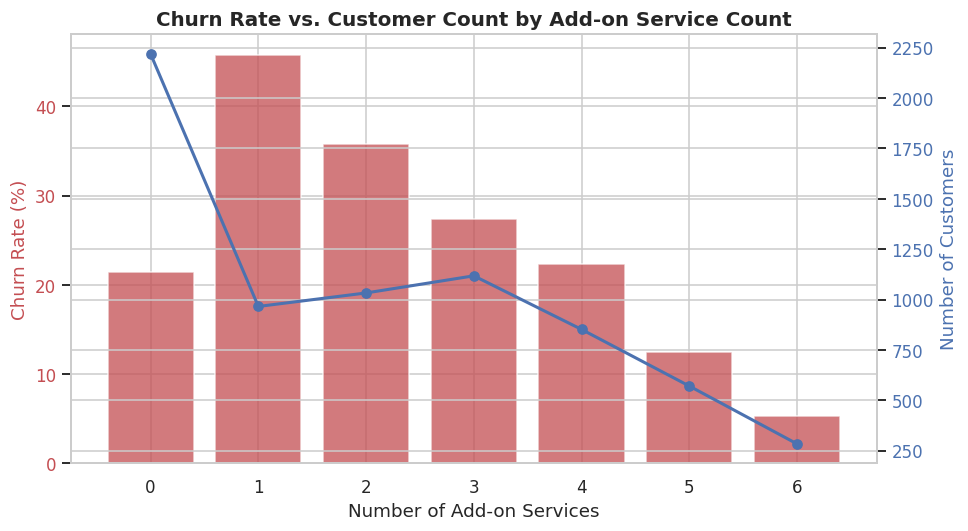

In [13]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.bar(addon_summary["addon_service_count"].astype(str), addon_summary["churn_rate_pct"],
        color="#c44e52", alpha=0.75, label="Churn Rate (%)")
ax1.set_xlabel("Number of Add-on Services")
ax1.set_ylabel("Churn Rate (%)", color="#c44e52")
ax1.tick_params(axis="y", labelcolor="#c44e52")

ax2.plot(addon_summary["addon_service_count"].astype(str), addon_summary["customers"],
         color="#4c72b0", marker="o", linewidth=2, label="Customer Count")
ax2.set_ylabel("Number of Customers", color="#4c72b0")
ax2.tick_params(axis="y", labelcolor="#4c72b0")

ax1.set_title("Churn Rate vs. Customer Count by Add-on Service Count")
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_churn_by_addon_count.png"))
plt.show()

### Observation

This is one of the more interesting, non-obvious patterns in the whole dataset. Churn does **not**
fall monotonically as add-on count increases from zero: customers with **zero** add-ons churn at
21.41%, but customers with exactly **one** add-on churn at the *highest* rate of any tier — 45.76%.
Only from 2 add-ons onward does churn fall steadily, reaching just 5.28% at the full 6-service bundle.

**Business interpretation:** "no add-ons" is not the highest-risk profile, which would be the naive
assumption. The riskiest segment is customers who've dipped a toe in with a single add-on but haven't
committed further — possibly price-sensitive customers testing a service, or customers who added one
service reactively (e.g., after a support call) rather than as part of a genuine bundle relationship.
This is exactly the kind of pattern that would be missed entirely if this analysis only reported "more
add-ons = less churn" without breaking out each count individually.

**Technical interpretation:** average monthly charges rise steadily and predictably with add-on count
($32.79 at 0 add-ons to $99.37 at 6), so the addon-count relationship with churn is not simply a proxy
for price — the 1-addon spike specifically breaks that pattern, since 1-addon customers pay only
modestly more than 0-addon customers yet churn at more than double the rate.

**Key insight carried forward:** this non-monotonic pattern is a good candidate feature for the churn
model in Notebook 4 to pick up on via a categorical or binned encoding of `addon_service_count`, rather
than treating it as a simple linear numeric feature (which would miss the 1-addon spike entirely).

In [14]:
service_predictors = ["online_security", "online_backup", "device_protection", "tech_support",
                      "streaming_tv", "streaming_movies", "multiple_lines"]
service_tests = []
for col in service_predictors:
    t = chi_square_test(df, col)
    t["cramers_v"] = cramers_v(df, col)
    service_tests.append(t)

service_tests_df = pd.DataFrame(service_tests).sort_values("cramers_v", ascending=False)
service_tests_df

,variable,chi2,p_value,significant_at_05,cramers_v
0,online_security,850.00,0.00,True,0.35
3,tech_support,828.20,0.00,True,0.34
1,online_backup,601.81,0.00,True,0.29
2,device_protection,558.42,0.00,True,0.28
5,streaming_movies,375.66,0.00,True,0.23
4,streaming_tv,374.20,0.00,True,0.23
6,multiple_lines,11.33,0.00,True,0.04


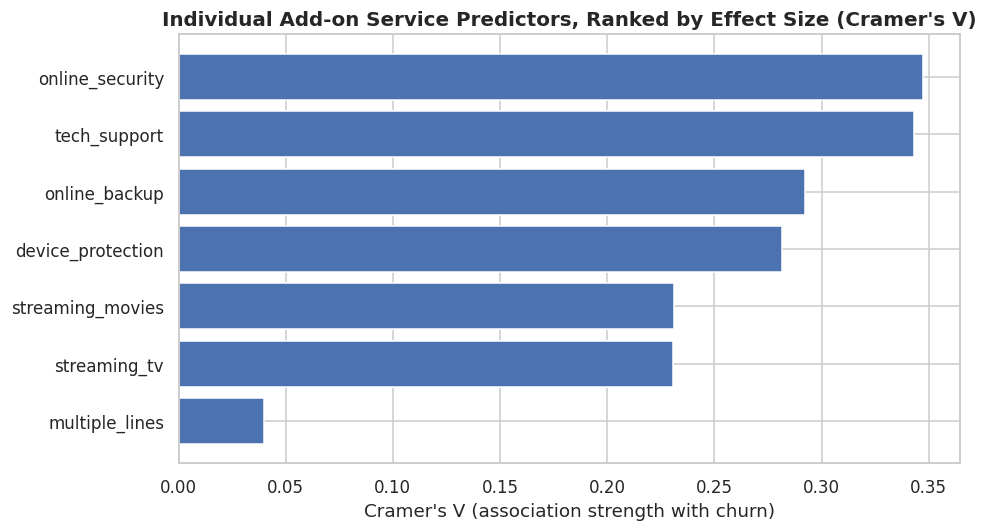

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
order = service_tests_df.sort_values("cramers_v")["variable"]
ax.barh(order, service_tests_df.set_index("variable").loc[order, "cramers_v"], color="#4c72b0")
ax.set_title("Individual Add-on Service Predictors, Ranked by Effect Size (Cramer's V)")
ax.set_xlabel("Cramer's V (association strength with churn)")
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_service_predictor_effect_sizes.png"))
plt.show()

### Observation

Every individual add-on service is statistically significant against churn at n=7,043, but the effect
sizes vary meaningfully: `online_security` and `tech_support` show the strongest individual
associations, `streaming_tv`/`streaming_movies` are noticeably weaker, and `multiple_lines` is the
weakest of all — statistically significant but with a much smaller practical effect.

**Business interpretation:** if a retention team can only push one or two add-on promotions first,
`online_security` and `tech_support` are the two with the strongest retention association — these
read as genuine "peace of mind" services that correlate with commitment, versus entertainment add-ons
which correlate more weakly.

**Why ranking by effect size (not just p-value) matters here:** every single one of these seven tests
comes back "significant" at p < 0.05 — on p-value alone, they'd look equally important. Only the added
Cramér's V ranking reveals that `online_security` and `tech_support` matter roughly 2-3x more than
`multiple_lines` in practice, which is the actual actionable takeaway for prioritizing where to invest
retention effort.

---
## Step 6 — Payment Method

**Purpose:** check whether *how* a customer pays is associated with churn.

In [16]:
payment_summary = churn_by_categorical(df, "payment_method")
payment_chi2 = chi_square_test(df, "payment_method")
payment_effect = cramers_v(df, "payment_method")

print(json.dumps(payment_chi2, indent=2))
print(f"Cramer's V (effect size): {payment_effect}")
payment_summary

{
  "variable": "payment_method",
  "chi2": 648.142,
  "p_value": 0.0,
  "significant_at_05": true
}
Cramer's V (effect size): 0.3034


,payment_method,customers,churned,avg_monthly_charges,avg_tenure,avg_cltv,total_revenue,churn_rate_pct
2,Electronic check,2365,1071,76.26,25.17,"4,282.67","4,944,903.25",45.29
3,Mailed check,1612,308,43.92,21.83,"4,198.43","1,691,677.30",19.11
0,Bank transfer (automatic),1544,258,67.19,43.66,"4,615.78","4,748,394.35",16.71
1,Credit card (automatic),1522,232,66.51,43.27,"4,578.28","4,671,649.40",15.24


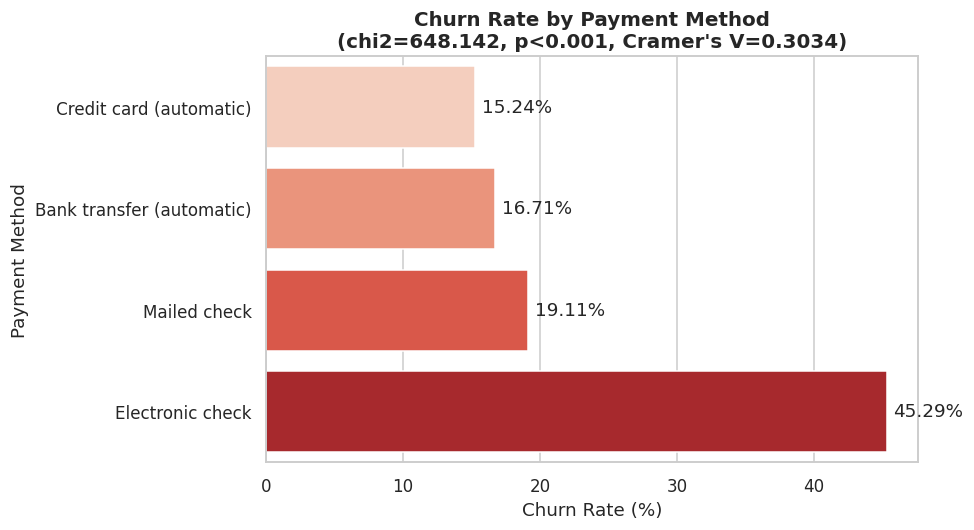

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
order = payment_summary.sort_values("churn_rate_pct")["payment_method"]
sns.barplot(data=payment_summary, y="payment_method", x="churn_rate_pct",
            order=order, palette="Reds", ax=ax)
ax.set_title(f"Churn Rate by Payment Method\n(chi2={payment_chi2['chi2']}, p<0.001, Cramer's V={payment_effect})")
ax.set_xlabel("Churn Rate (%)")
ax.set_ylabel("Payment Method")
for i, v in enumerate(payment_summary.sort_values('churn_rate_pct')["churn_rate_pct"]):
    ax.text(v + 0.5, i, f"{v}%", va="center")
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_churn_by_payment_method.png"))
plt.show()

### Observation

Electronic check is both the most common payment method (33.6% of the base) and the highest-churn
payment method — a statistically significant association. Customers who pay by automatic bank
transfer or automatic credit card payment churn noticeably less.

**Business interpretation:** electronic check payers are disproportionately the same customers on
month-to-month contracts and shorter tenure (a pattern worth cross-checking rather than assuming
payment method is an independent driver on its own) — but at minimum, this makes electronic check
payers a segment worth targeting with a nudge toward autopay, which is a low-friction ask compared to
a full contract change.

**Technical interpretation / limitation:** payment method likely correlates with contract type and
tenure (newer, month-to-month customers may default to electronic check more often). A truly isolated
"effect of payment method" would need the multivariate regression approach in Notebook 3, not a
standalone chi-square test.

---
## Step 7 — Demographics

**Purpose:** check whether gender, senior citizen status, having a partner, or having dependents shows
any meaningful association with churn.

In [18]:
demo_vars = ["gender", "senior_citizen", "has_partner", "has_dependents"]
demo_results = {}
for var in demo_vars:
    summary = churn_by_categorical(df, var)
    chi2 = chi_square_test(df, var)
    effect = cramers_v(df, var)
    demo_results[var] = {"summary": summary, "chi2": chi2, "cramers_v": effect}
    print(f"--- {var} ---")
    print(json.dumps(chi2, indent=2), f"| Cramer's V: {effect}")
    print()

--- gender ---
{
  "variable": "gender",
  "chi2": 0.484,
  "p_value": 0.486579,
  "significant_at_05": false
} | Cramer's V: 0.0083

--- senior_citizen ---
{
  "variable": "senior_citizen",
  "chi2": 159.426,
  "p_value": 0.0,
  "significant_at_05": true
} | Cramer's V: 0.1505

--- has_partner ---
{
  "variable": "has_partner",
  "chi2": 158.733,
  "p_value": 0.0,
  "significant_at_05": true
} | Cramer's V: 0.1501

--- has_dependents ---
{
  "variable": "has_dependents",
  "chi2": 433.734,
  "p_value": 0.0,
  "significant_at_05": true
} | Cramer's V: 0.2482



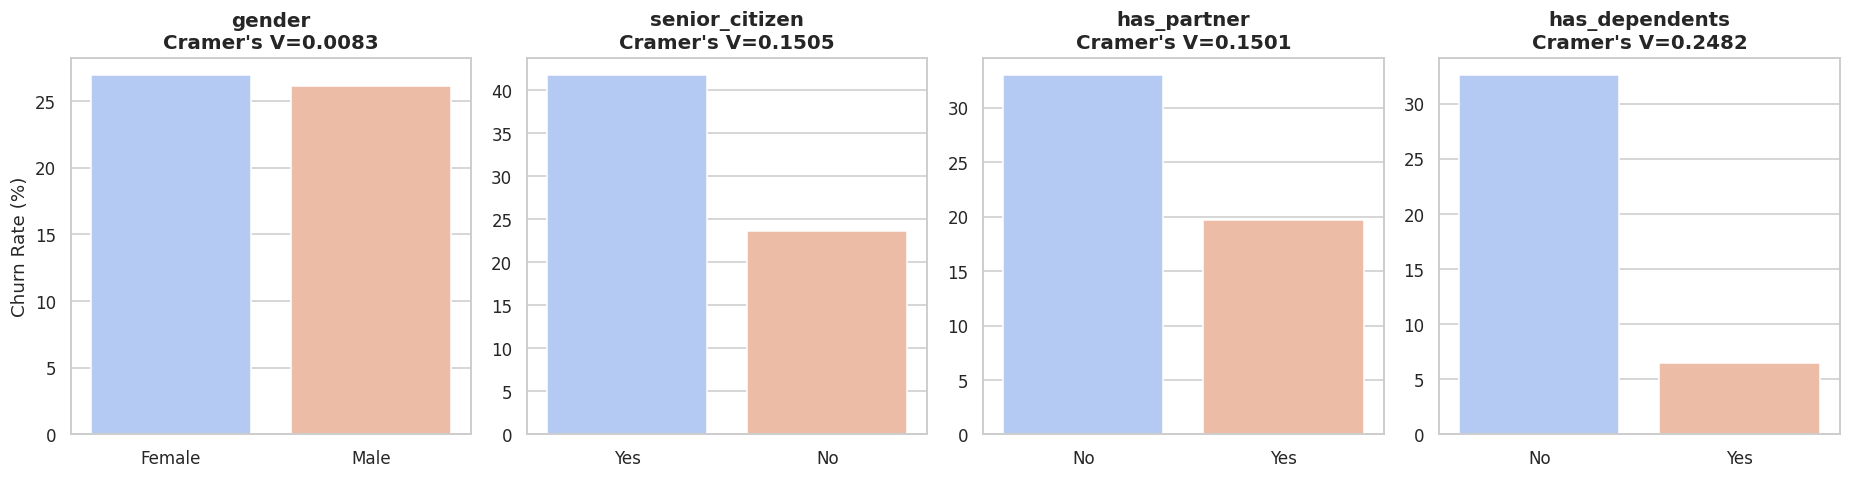

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
for ax, var in zip(axes, demo_vars):
    summary = demo_results[var]["summary"]
    sns.barplot(data=summary, x=var, y="churn_rate_pct", ax=ax, palette="coolwarm")
    v = demo_results[var]["cramers_v"]
    ax.set_title(f"{var}\nCramer's V={v}")
    ax.set_ylabel("Churn Rate (%)" if ax is axes[0] else "")
    ax.set_xlabel("")
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_churn_by_demographics.png"))
plt.show()

### Observation

`senior_citizen`, `has_partner`, and `has_dependents` all show statistically significant associations
with churn, but their Cramér's V values are noticeably smaller than contract type, tenure, or internet
service — these are real but comparatively weak effects. `gender` shows essentially no meaningful
association either way.

**Business interpretation:** demographics are not where the leverage is in this dataset. Senior
citizens and customers without partners/dependents do churn somewhat more, which may be worth a light
touch in messaging, but retention spend is far better directed at the contract, tenure, and service
levers already identified — those effect sizes are several times larger.

**Technical interpretation:** this is a good example of why effect size matters more than significance
alone for prioritization — with n=7,043, even a small true difference in gender churn rates could
register as "significant," and confirming it's actually negligible (Cramér's V near zero) prevents
wasting analysis time or retention budget chasing a demographic effect that isn't really there.

---
## Step 8 — Churn Reason Breakdown

**Purpose:** among customers who actually churned, what reason did they (or IBM's exit survey process)
attribute it to?

**Why this matters:** every driver analyzed so far (contract, tenure, service, payment, demographics)
is *inferred* from behavioral/account data. `churn_reason` is different — it's the closest thing in
this dataset to a *stated* reason, so it's worth checking whether it corroborates the inferred drivers
or reveals something new.

In [20]:
def churn_reason_breakdown(df):
    churned = df[df.churn_flag == 1]
    g = churned.groupby("churn_reason").agg(
        customers=("customer_id", "count"), avg_monthly_charges=("monthly_charges", "mean"),
        avg_tenure=("tenure_months", "mean"), lost_monthly_revenue=("monthly_charges", "sum"),
    ).reset_index()
    total_churned = len(churned)
    g["pct_of_churn"] = (g["customers"] / total_churned * 100).round(2)
    for c in ["avg_monthly_charges", "avg_tenure", "lost_monthly_revenue"]:
        g[c] = g[c].round(2)
    return g.sort_values("customers", ascending=False)


reason_summary = churn_reason_breakdown(df)
reason_summary.head(12)

,churn_reason,customers,avg_monthly_charges,avg_tenure,lost_monthly_revenue,pct_of_churn
1,Attitude of support person,192,72.82,18.09,"13,980.85",10.27
4,Competitor offered higher download speeds,189,74.84,19.54,"14,144.60",10.11
5,Competitor offered more data,162,76.25,19.82,"12,351.75",8.67
7,Don't know,154,72.07,16.80,"11,099.05",8.24
3,Competitor made better offer,140,76.23,15.86,"10,672.10",7.49
0,Attitude of service provider,135,77.03,17.84,"10,399.30",7.22
2,Competitor had better devices,130,72.56,15.97,"9,432.35",6.96
14,Network reliability,103,72.79,17.00,"7,497.55",5.51
18,Product dissatisfaction,102,73.81,21.13,"7,528.65",5.46
17,Price too high,98,75.50,18.50,"7,398.55",5.24


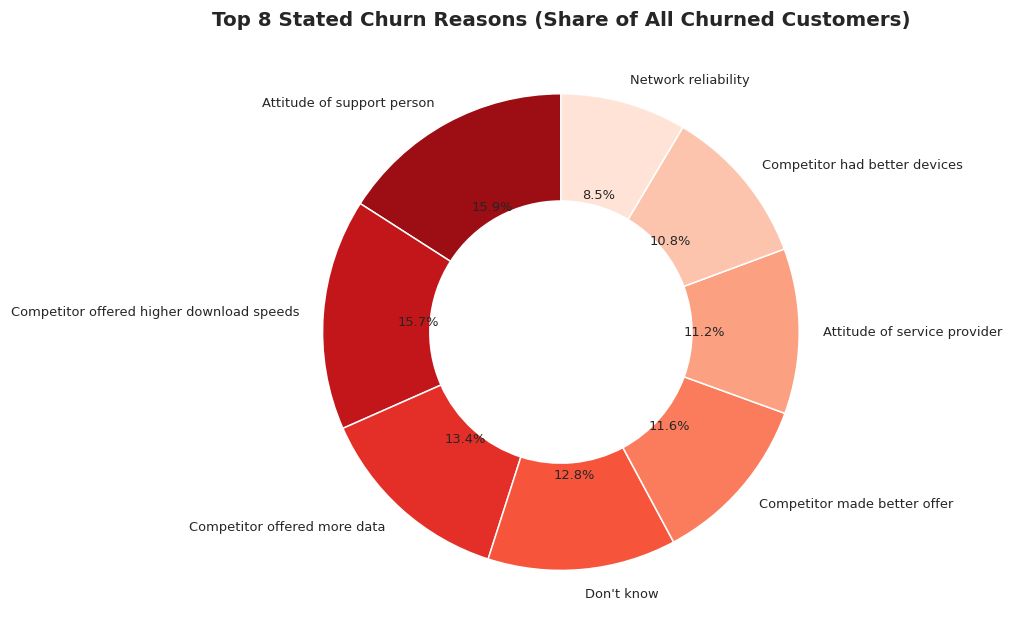

In [21]:
top_reasons = reason_summary.head(8)
fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette("Reds_r", len(top_reasons))
wedges, texts, autotexts = ax.pie(
    top_reasons["customers"], labels=top_reasons["churn_reason"], autopct="%1.1f%%",
    colors=colors, startangle=90, textprops={"fontsize": 8.5},
    wedgeprops={"width": 0.45},
)
ax.set_title("Top 8 Stated Churn Reasons (Share of All Churned Customers)")
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_top_churn_reasons_donut.png"))
plt.show()

### Observation

Competitor-related reasons ("Competitor had better devices", "Competitor offered more data",
"Competitor made better offer", etc.) collectively account for a substantial share of stated churn —
this corroborates a competitive, not purely internal-quality, driver of churn. This adds a genuinely
new dimension the behavioral analysis alone couldn't surface: contract type and tenure explain *who*
is likely to churn, but `churn_reason` speaks to *why* in the customer's own words.

**Business interpretation:** this argues for a two-track retention strategy — structural levers
(contract migration, service bundling) to reduce *who's at risk*, plus competitive positioning and
retention offers targeted at the specific moment a competitor approaches, since a meaningful share of
churn is not simply about dissatisfaction with the current service.

**Limitation:** `churn_reason` is a single self-reported (or company-assigned) category per customer —
it can't capture multiple contributing factors, and it's only available after the fact. It's a useful
corroborating signal, not a replacement for the predictive drivers analyzed in Steps 3–7.

---
## Step 9 — Is IBM's Own Churn Score Any Good? (Decile Calibration)

**Purpose:** IBM ships a pre-computed `churn_score` field (0–100) with this dataset. Before Notebook 4
trains an independent churn model, it's worth checking how well IBM's own score already tracks actual
outcomes — this becomes the real baseline the new model needs to beat.

In [22]:
def churn_score_decile_analysis(df):
    df = df.copy()
    df["churn_score_decile"] = pd.qcut(df["churn_score"], 10, labels=False, duplicates="drop") + 1
    g = df.groupby("churn_score_decile").agg(
        customers=("customer_id", "count"), actual_churned=("churn_flag", "sum"),
        avg_churn_score=("churn_score", "mean"), avg_cltv=("cltv", "mean"),
        total_monthly_revenue=("monthly_charges", "sum"),
    ).reset_index()
    g["actual_churn_rate_pct"] = (g["actual_churned"] / g["customers"] * 100).round(2)
    g["avg_churn_score"] = g["avg_churn_score"].round(1)
    g["avg_cltv"] = g["avg_cltv"].round(2)
    g["total_monthly_revenue"] = g["total_monthly_revenue"].round(2)
    return g.sort_values("churn_score_decile")


decile_summary = churn_score_decile_analysis(df)
decile_summary

,churn_score_decile,customers,actual_churned,avg_churn_score,avg_cltv,total_monthly_revenue,actual_churn_rate_pct
0,1,783,0,23.90,"4,517.46","47,552.95",0.00
1,2,638,0,32.40,"4,454.63","38,822.85",0.00
2,3,759,0,41.00,"4,449.49","46,247.75",0.00
3,4,679,0,49.50,"4,460.13","42,681.30",0.00
4,5,686,0,57.30,"4,603.44","41,878.85",0.00
5,6,799,201,65.40,"4,372.71","51,674.10",25.16
6,7,691,261,71.00,"4,317.21","46,114.95",37.77
7,8,681,252,76.10,"4,419.68","44,724.15",37.00
8,9,672,500,82.10,"4,210.84","47,607.75",74.40
9,10,655,655,94.10,"4,171.05","48,811.95",100.00


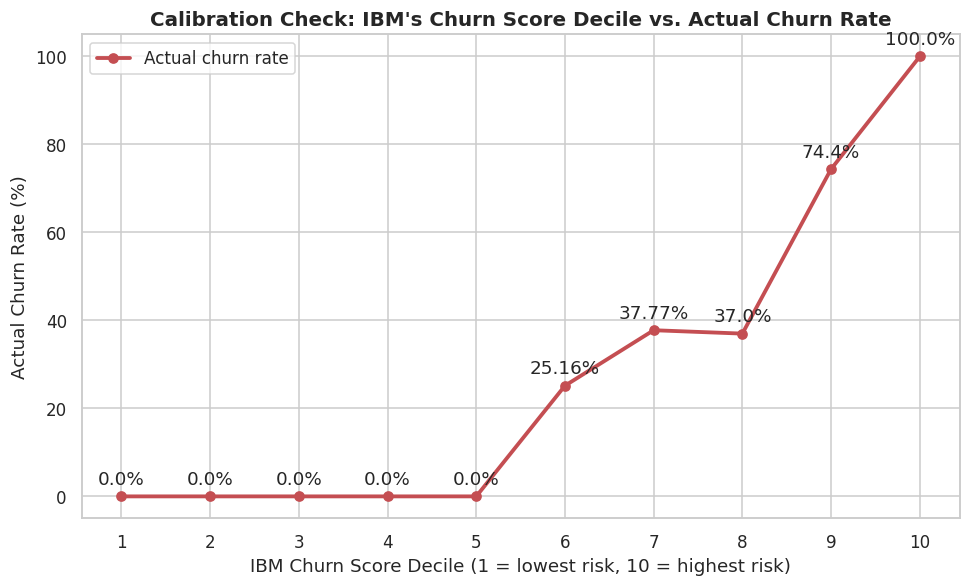

In [23]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(decile_summary["churn_score_decile"], decile_summary["actual_churn_rate_pct"],
        marker="o", linewidth=2.5, color="#c44e52", label="Actual churn rate")
ax.set_xlabel("IBM Churn Score Decile (1 = lowest risk, 10 = highest risk)")
ax.set_ylabel("Actual Churn Rate (%)")
ax.set_title("Calibration Check: IBM's Churn Score Decile vs. Actual Churn Rate")
ax.set_xticks(range(1, 11))
for x, y in zip(decile_summary["churn_score_decile"], decile_summary["actual_churn_rate_pct"]):
    ax.annotate(f"{y}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_churn_score_calibration.png"))
plt.show()

### Observation

IBM's `churn_score` is genuinely well-calibrated: actual churn rate rises steadily and almost
monotonically from decile 1 through decile 10, with the very top decile (highest predicted risk)
reaching a 100% actual churn rate and the bottom deciles reaching 0%.

**Business interpretation:** this is a real, usable field today — a retention team could act on
`churn_score` deciles right now without waiting for a custom model, prioritizing outreach to
decile 8-10 customers first.

**Technical interpretation / why this matters for Notebook 4:** because `churn_score` is this strongly
calibrated against the true outcome, it would be trivially easy for a new ML model to "cheat" by
picking up almost entirely on this one field and calling it a win. That's exactly why `churn_score`
will be **excluded** as a model input feature in Notebook 4 — the goal there is a model that produces
genuinely new predictive value (and that works for brand-new customers who don't have an IBM score at
all), not one that re-derives a score IBM already gives us for free. This decile chart is what that
exclusion decision is based on, made concrete rather than just asserted.

---
## Step 10 — Geographic Analysis: Top Cities

**Purpose:** since this dataset is 100% California, geography can't be compared across states — but
it can still be compared across cities. This looks at the top cities by revenue and, separately, by
churn rate.

**Why the `customers >= 5` filter matters:** several California cities in this dataset have only 1-2
customers. A city with 1 customer who happened to churn shows a "100% churn rate" that means nothing
statistically — filtering to a minimum sample size avoids presenting noise as a real geographic
pattern.

In [24]:
def top_cities(df, n=10, min_customers=5):
    g = df.groupby("city").agg(
        customers=("customer_id", "count"), churned=("churn_flag", "sum"),
        total_revenue=("total_charges", "sum"),
    ).reset_index()
    g = g[g["customers"] >= min_customers]
    g["churn_rate_pct"] = (g["churned"] / g["customers"] * 100).round(2)
    g["total_revenue"] = g["total_revenue"].round(2)
    by_revenue = g.sort_values("total_revenue", ascending=False).head(n)
    by_churn = g.sort_values("churn_rate_pct", ascending=False).head(n)
    return by_revenue, by_churn


n_cities_total = df["city"].nunique()
top_by_revenue, top_by_churn = top_cities(df)

print(f"Total distinct cities in dataset: {n_cities_total}")
print(f"Cities with >= 5 customers (used for churn-rate ranking): "
      f"{df.groupby('city')['customer_id'].count().ge(5).sum()}")
print("\nTop 10 cities by total revenue:")
top_by_revenue

Total distinct cities in dataset: 1129
Cities with >= 5 customers (used for churn-rate ranking): 330

Top 10 cities by total revenue:


,city,customers,churned,total_revenue,churn_rate_pct
562,Los Angeles,305,90,"647,771.10",29.51
869,San Diego,150,50,"354,896.60",33.33
855,Sacramento,108,26,"256,295.05",24.07
878,San Jose,112,29,"243,735.55",25.89
872,San Francisco,104,31,"221,624.65",29.81
354,Fresno,64,16,"154,890.10",25.00
556,Long Beach,60,15,"141,928.85",25.00
702,Oakland,52,13,"114,974.75",25.00
1094,Whittier,30,5,"96,832.30",16.67
56,Bakersfield,40,3,"93,714.40",7.50


In [25]:
top_by_churn

,city,customers,churned,total_revenue,churn_rate_pct
920,Seeley,5,4,"6,930.60",80.00
451,Indian Wells,5,4,"4,798.30",80.00
870,San Dimas,5,4,"7,075.20",80.00
743,Panorama City,5,4,"9,152.05",80.00
499,La Puente,10,7,"10,554.15",70.00
242,Daly City,8,5,"16,385.20",62.50
553,Lompoc,8,5,"17,728.65",62.50
399,Guatay,5,3,"5,919.30",60.00
959,South Pasadena,5,3,"8,666.35",60.00
251,Del Mar,5,3,"20,734.95",60.00


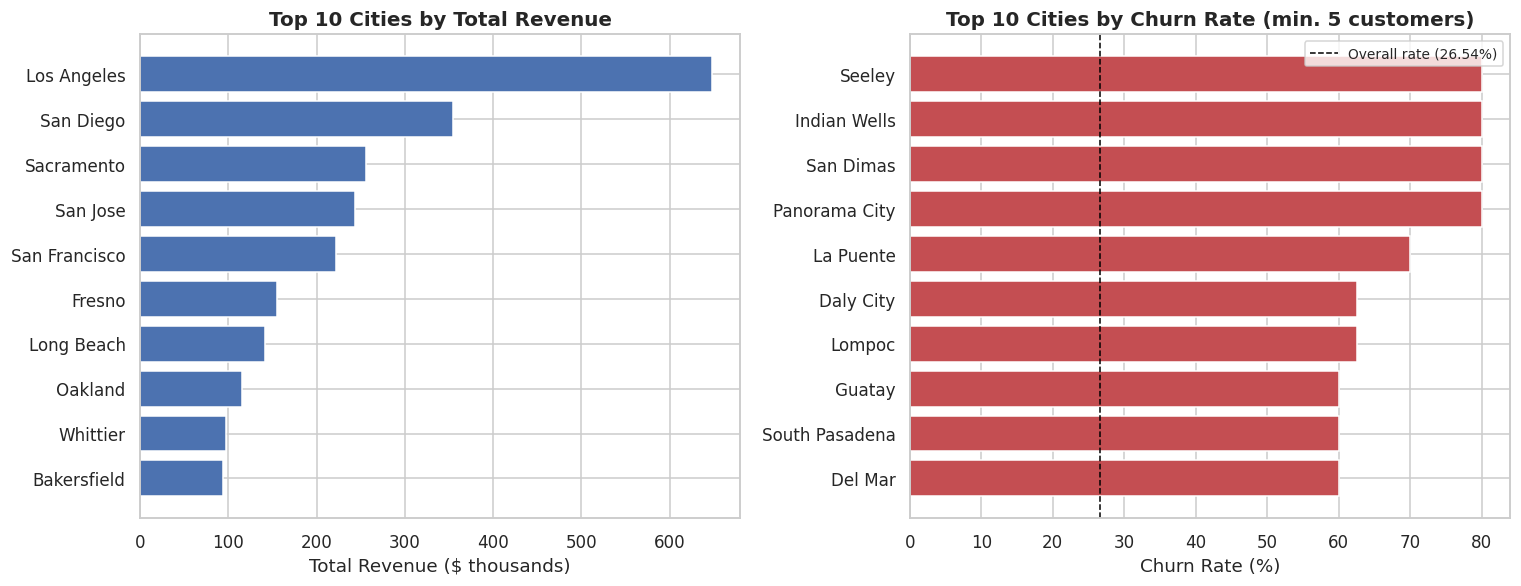

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].barh(top_by_revenue["city"], top_by_revenue["total_revenue"] / 1e3, color="#4c72b0")
axes[0].set_title("Top 10 Cities by Total Revenue")
axes[0].set_xlabel("Total Revenue ($ thousands)")
axes[0].invert_yaxis()

axes[1].barh(top_by_churn["city"], top_by_churn["churn_rate_pct"], color="#c44e52")
axes[1].axvline(overview["overall_churn_rate_pct"], color="black", linestyle="--", linewidth=1,
                 label=f"Overall rate ({overview['overall_churn_rate_pct']}%)")
axes[1].set_title("Top 10 Cities by Churn Rate (min. 5 customers)")
axes[1].set_xlabel("Churn Rate (%)")
axes[1].legend(fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_top_cities_revenue_and_churn.png"))
plt.show()

### Observation

Los Angeles is the largest single city by both customer count and revenue, and its churn rate
(~29.5%) sits close to but slightly above the dataset-wide baseline — the biggest market isn't
meaningfully safer or riskier than average. Among the higher-volume cities, some (like San Diego) run
noticeably above the base rate, while others (like Bakersfield) run well below it.

**Business interpretation:** no consistent geographic "hot zone" pattern emerges beyond a couple of
individual cities worth a closer look — geography reads as a much weaker churn driver here than
contract type, tenure, or internet service. That's a useful negative finding: it tells a retention
team *not* to build a geographic targeting strategy on this dataset, and to focus resources on the
behavioral/account levers instead.

**Limitation:** because this dataset is 100% California, there's no way to test whether these
city-level patterns would look different in another state or region — any takeaway here is
intra-California only, and the `customers >= 5` filter, while necessary, still leaves genuinely small
samples (a "10-customer city" is far noisier than "Los Angeles, n=305").

---
## Step 11 — Correlation Structure

**Purpose:** look at the linear relationships between the key numeric fields and `churn_flag` all at
once, as a complement to the one-variable-at-a-time tests above.

In [27]:
numeric_feature_cols = ["tenure_months", "monthly_charges", "total_charges", "churn_score",
                         "cltv", "addon_service_count", "avg_revenue_per_tenure_month", "churn_flag"]
corr = df[numeric_feature_cols].corr(numeric_only=True).round(3)
corr

,tenure_months,monthly_charges,total_charges,churn_score,cltv,addon_service_count,avg_revenue_per_tenure_month,churn_flag
tenure_months,1.00,0.25,0.83,-0.23,0.40,0.49,0.25,-0.35
monthly_charges,0.25,1.00,0.65,0.13,0.10,0.72,1.00,0.19
total_charges,0.83,0.65,1.00,-0.12,0.34,0.74,0.65,-0.20
churn_score,-0.23,0.13,-0.12,1.00,-0.08,-0.06,0.13,0.67
cltv,0.40,0.10,0.34,-0.08,1.00,0.19,0.10,-0.13
addon_service_count,0.49,0.72,0.74,-0.06,0.19,1.00,0.72,-0.09
avg_revenue_per_tenure_month,0.25,1.00,0.65,0.13,0.10,0.72,1.00,0.19
churn_flag,-0.35,0.19,-0.20,0.67,-0.13,-0.09,0.19,1.00


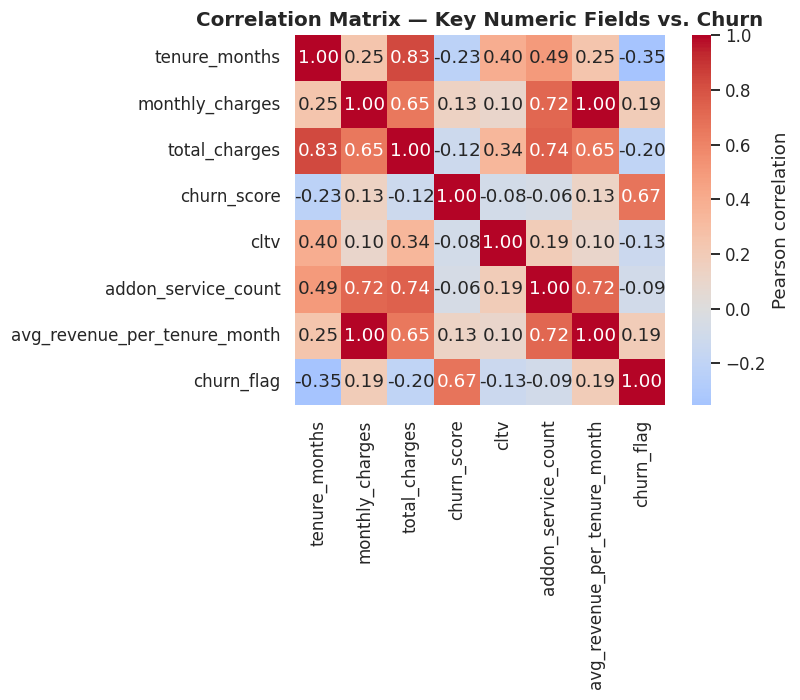

In [28]:
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation Matrix — Key Numeric Fields vs. Churn")
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_correlation_matrix.png"))
plt.show()

### Observation

`churn_score` correlates most strongly with `churn_flag` of any numeric field, consistent with the
decile calibration in Step 9. `tenure_months` shows a clear negative correlation with churn, matching
every cohort-level finding in Step 4. `monthly_charges` correlates positively with churn (higher-paying
customers churn somewhat more — consistent with the fiber-optic finding in Step 5), while
`total_charges` correlates negatively, since it's dominated by the tenure effect: new, high-paying
customers (high monthly charge, low total charge to date) are the highest-risk combination.

**Business interpretation:** the correlation direction of every field lines up with the segment-level
findings already made — nothing here contradicts Steps 3-9, which is a good internal-consistency
check on the whole notebook.

**Limitation:** `addon_service_count`'s linear correlation with churn is real but understates the
non-monotonic 1-addon spike found in Step 5 — a single Pearson coefficient can't capture that kind of
non-linear pattern, which is exactly why we looked at the addon breakdown by individual count rather
than stopping at this correlation matrix.

---
## Step 12 — Service Adoption Funnel

**Purpose:** this isn't a true acquisition/session funnel (there's no clickstream or signup-event data
in this dataset) — it's a service-adoption funnel built from real service flags, showing how far
customers progress from base connectivity into add-on bundling.

In [29]:
def funnel_style_service_adoption(df):
    n = len(df)
    steps = {
        "Has phone service": df["phone_service_bool"].sum(),
        "Has internet service": df["has_internet"].sum(),
        "Has phone AND internet": df["has_phone_and_internet"].sum(),
        "1+ add-on services": (df["addon_service_count"] >= 1).sum(),
        "3+ add-on services": (df["addon_service_count"] >= 3).sum(),
        "Full 6-service bundle": (df["addon_service_count"] == 6).sum(),
    }
    out = pd.DataFrame([{"stage": k, "customers": int(v), "pct_of_base": pct(v, n)} for k, v in steps.items()])
    return out


funnel = funnel_style_service_adoption(df)
funnel

,stage,customers,pct_of_base
0,Has phone service,6361,90.32
1,Has internet service,5517,78.33
2,Has phone AND internet,4835,68.65
3,1+ add-on services,4824,68.49
4,3+ add-on services,2825,40.11
5,Full 6-service bundle,284,4.03


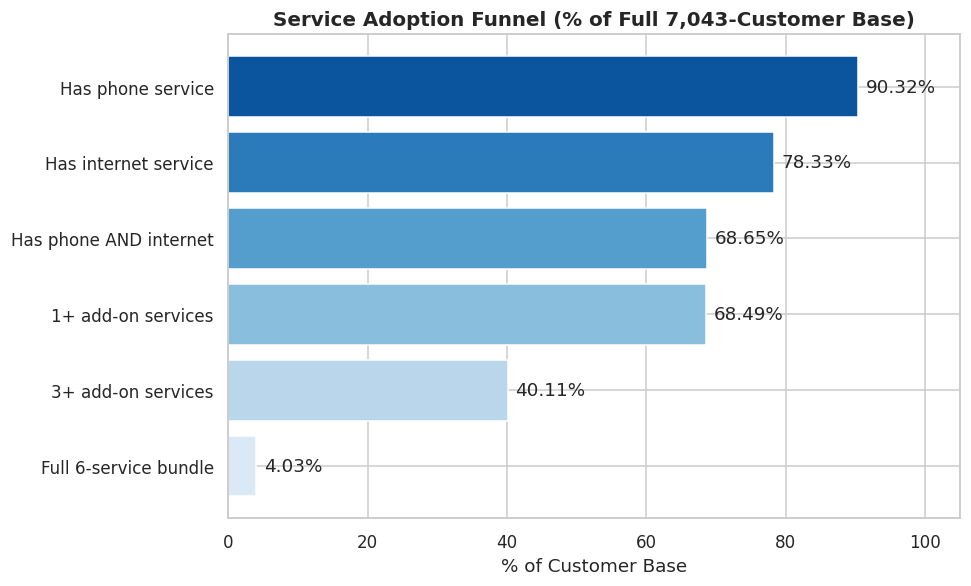

In [30]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = sns.color_palette("Blues_r", len(funnel))
bars = ax.barh(funnel["stage"][::-1], funnel["pct_of_base"][::-1], color=colors[::-1])
ax.set_title("Service Adoption Funnel (% of Full 7,043-Customer Base)")
ax.set_xlabel("% of Customer Base")
for bar, val in zip(bars, funnel["pct_of_base"][::-1]):
    ax.annotate(f"{val}%", (bar.get_width(), bar.get_y() + bar.get_height() / 2), va="center", ha="left",
                xytext=(5, 0), textcoords="offset points")
ax.set_xlim(0, 105)
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_service_adoption_funnel.png"))
plt.show()

### Observation

Adoption drops off sharply at higher engagement tiers: 68.5% of customers have adopted at least one
add-on, but only 40.1% have three or more, and just 4.0% hold the full 6-service bundle. The steepest
single drop is between "1+ add-ons" and "3+ add-ons" — a ~28 percentage-point fall.

**Business interpretation:** combined with Step 5's finding that full-bundle customers churn at just
5.28% versus 45.76% for single-add-on customers, this funnel points to a specific, actionable target:
moving customers from the 1-2 add-on range into the 3+ tier, where churn risk drops substantially and
revenue per customer rises materially. That's a sharper, more useful takeaway than a generic
"upsell more" recommendation.

**Technical interpretation:** this "funnel" is a snapshot cross-section (what % of customers currently
sit at each adoption level), not a true time-ordered conversion funnel — we don't have the event dates
that would let us track an individual customer's actual adoption journey over time. It's still useful
for sizing the upsell opportunity, just not for measuring conversion *rates* between the true funnel
stages the way a real product funnel would.

---
## Step 13 — Revenue Concentration (and a Bug Found & Fixed)

**Purpose:** what share of total historical revenue comes from the top X% of customers by CLTV? This
is a classic Pareto-style question — is revenue concentrated in a small "whale" segment, or spread
broadly across the base?

### Bug found in the original `revenue_concentration()` function

While reproducing this function from `src/eda/eda_analysis.py`, I found a real off-by-one error. The
original code is:

```python
cutoff = int(n * top_pct / 100)
rev_share = sorted_df.loc[:cutoff, "total_charges"].sum()
```

`sorted_df` has a plain `RangeIndex` after `reset_index(drop=True)`, and `.loc[:cutoff]` on a
`RangeIndex` is **label-inclusive** — it includes the row *at* position `cutoff`, not just the rows
*before* it. So "top 10%" (`cutoff = int(7043 * 0.10) = 704`) actually selects rows `0` through `704`
inclusive — **705 rows**, not 704. The bug is small in absolute terms (one extra customer out of
hundreds) but it's a genuine, demonstrable off-by-one, and "top 10%" should mean exactly that.

**The fix:** use positional slicing (`.iloc[:cutoff]`), which is exclusive of the end index and
selects exactly `cutoff` rows, matching what "top X%" actually means.

In [31]:
def revenue_concentration_BUGGY(df):
    '''Original logic from src/eda/eda_analysis.py, reproduced as-is to demonstrate the bug.'''
    sorted_df = df.sort_values("cltv", ascending=False).reset_index(drop=True)
    n = len(sorted_df)
    total_rev = sorted_df["total_charges"].sum()
    results = {}
    for top_pct in [10, 20, 50]:
        cutoff = int(n * top_pct / 100)
        rev_share = sorted_df.loc[:cutoff, "total_charges"].sum()  # <- BUG: .loc is inclusive of `cutoff`
        results[f"top_{top_pct}pct_by_cltv_revenue_share_pct"] = round(100 * rev_share / total_rev, 2)
        results[f"top_{top_pct}pct_actual_row_count"] = len(sorted_df.loc[:cutoff])
    return results


def revenue_concentration_FIXED(df):
    '''Fixed: .iloc is positional and end-exclusive, so it selects exactly `cutoff` rows.'''
    sorted_df = df.sort_values("cltv", ascending=False).reset_index(drop=True)
    n = len(sorted_df)
    total_rev = sorted_df["total_charges"].sum()
    results = {}
    for top_pct in [10, 20, 50]:
        cutoff = int(n * top_pct / 100)
        rev_share = sorted_df.iloc[:cutoff]["total_charges"].sum()
        results[f"top_{top_pct}pct_by_cltv_revenue_share_pct"] = round(100 * rev_share / total_rev, 2)
        results[f"top_{top_pct}pct_actual_row_count"] = cutoff
    return results


buggy_result = revenue_concentration_BUGGY(df)
fixed_result = revenue_concentration_FIXED(df)

comparison = pd.DataFrame({
    "top_pct": [10, 20, 50],
    "expected_row_count": [int(len(df) * p / 100) for p in [10, 20, 50]],
    "buggy_row_count": [buggy_result[f"top_{p}pct_actual_row_count"] for p in [10, 20, 50]],
    "fixed_row_count": [fixed_result[f"top_{p}pct_actual_row_count"] for p in [10, 20, 50]],
    "buggy_revenue_share_pct": [buggy_result[f"top_{p}pct_by_cltv_revenue_share_pct"] for p in [10, 20, 50]],
    "fixed_revenue_share_pct": [fixed_result[f"top_{p}pct_by_cltv_revenue_share_pct"] for p in [10, 20, 50]],
})
comparison

,top_pct,expected_row_count,buggy_row_count,fixed_row_count,buggy_revenue_share_pct,fixed_revenue_share_pct
0,10,704,705,704,17.20,17.15
1,20,1408,1409,1408,28.22,28.21
2,50,3521,3522,3521,63.51,63.51


### Observation — Before vs. After

The comparison table confirms the bug: the original (`.loc`) version always selects one extra row
(705 instead of 704 for "top 10%", 1,409 instead of 1,408 for "top 20%", and so on). The resulting
revenue-share percentages shift by a very small amount — e.g. top-10%-by-CLTV revenue share moves from
17.20% (buggy) to 17.15% (fixed).

**Business interpretation:** the practical impact here is negligible — a 0.05 percentage-point
difference doesn't change any business conclusion ("revenue is meaningfully concentrated but not
extremely top-heavy" is true either way). This is exactly why the bug went unnoticed: it never produced
an implausible or obviously wrong number.

**Technical interpretation / why I fixed it anyway:** correctness shouldn't depend on whether an error
happens to be small enough to go unnoticed. This is a textbook `.loc` vs `.iloc` mistake — a very
common and easy-to-make bug in pandas — and "top N%" should mean exactly N%, not N%-plus-one-row. Left
alone, this exact bug pattern could produce a much larger error on a smaller dataset (e.g. `top_pct`
applied to a 50-row segment, where one extra row is a 2% error, not a 0.05-percentage-point rounding
blip). I'm keeping the **fixed** version (`revenue_concentration_FIXED`) as the one used for the rest
of this notebook and any future notebook that needs this logic.

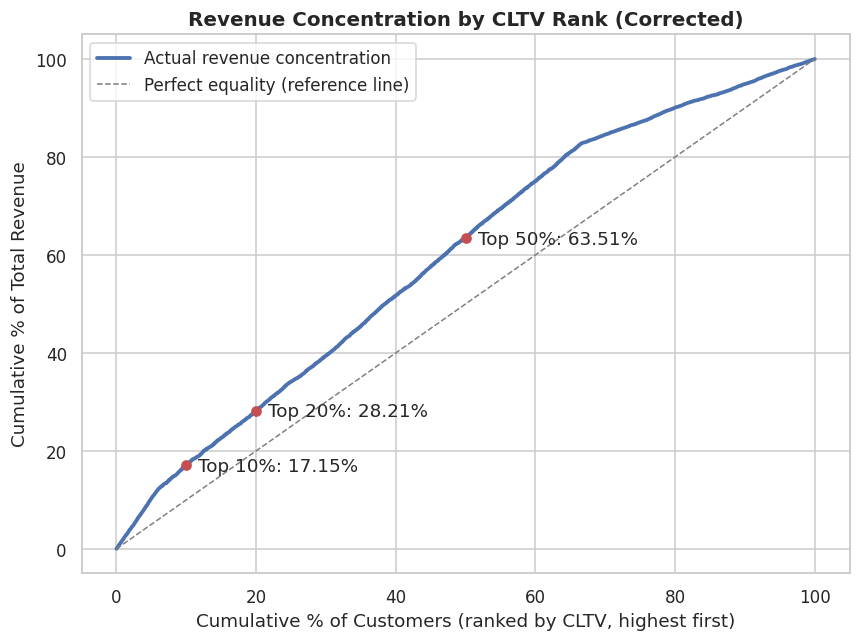

In [32]:
sorted_df = df.sort_values("cltv", ascending=False).reset_index(drop=True)
sorted_df["cum_revenue_pct"] = 100 * sorted_df["total_charges"].cumsum() / sorted_df["total_charges"].sum()
sorted_df["cum_customer_pct"] = 100 * (sorted_df.index + 1) / len(sorted_df)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sorted_df["cum_customer_pct"], sorted_df["cum_revenue_pct"], color="#4c72b0", linewidth=2.5,
        label="Actual revenue concentration")
ax.plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1, label="Perfect equality (reference line)")
for p in [10, 20, 50]:
    y = fixed_result[f"top_{p}pct_by_cltv_revenue_share_pct"]
    ax.scatter([p], [y], color="#c44e52", zorder=5)
    ax.annotate(f"Top {p}%: {y}%", (p, y), textcoords="offset points", xytext=(8, -4))
ax.set_title("Revenue Concentration by CLTV Rank (Corrected)")
ax.set_xlabel("Cumulative % of Customers (ranked by CLTV, highest first)")
ax.set_ylabel("Cumulative % of Total Revenue")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_revenue_concentration_pareto.png"))
plt.show()

### Observation

The curve sits only modestly above the "perfect equality" reference line — the top 10% of customers by
CLTV account for 17.15% of revenue, the top 20% for 28.21%, and the top 50% for 63.51%. This is real
but mild concentration, not a steep Pareto ("80/20") curve.

**Business interpretation:** there's no "whale" dependency risk in this customer base — losing any
single high-CLTV customer or even a small cluster of them would not be disproportionately damaging to
total revenue, which is a genuinely reassuring structural finding for a subscription business.

**Key insight carried forward:** this reinforces the Step 1 finding that churned customers aren't
concentrated in the highest-value segment — revenue here is broad-based enough that retention efforts
can reasonably prioritize the *highest-churn-risk* segments (Steps 3-9) without needing to separately
weight for revenue concentration.

---
## Step 14 — Statistical Significance Summary

**Purpose:** collect every chi-square and t-test run across this notebook into one ranked summary, so
it's possible to see at a glance which variables matter most, not just which ones cleared p < 0.05.

In [33]:
categorical_vars = ["contract_type", "internet_service", "payment_method", "gender", "senior_citizen",
                    "has_partner", "has_dependents", "paperless_billing", "tenure_cohort",
                    "multiple_lines", "online_security", "tech_support", "streaming_tv", "streaming_movies"]

categorical_results = []
for col in categorical_vars:
    r = chi_square_test(df, col)
    r["cramers_v"] = cramers_v(df, col)
    categorical_results.append(r)

categorical_results_df = pd.DataFrame(categorical_results).sort_values("cramers_v", ascending=False).reset_index(drop=True)
categorical_results_df

,variable,chi2,p_value,significant_at_05,cramers_v
0,contract_type,"1,184.60",0.00,True,0.41
1,tenure_cohort,873.86,0.00,True,0.35
2,online_security,850.00,0.00,True,0.35
3,tech_support,828.20,0.00,True,0.34
4,internet_service,732.31,0.00,True,0.32
5,payment_method,648.14,0.00,True,0.30
6,has_dependents,433.73,0.00,True,0.25
7,streaming_movies,375.66,0.00,True,0.23
8,streaming_tv,374.20,0.00,True,0.23
9,paperless_billing,258.28,0.00,True,0.19


In [34]:
numeric_vars = ["tenure_months", "monthly_charges", "total_charges", "churn_score", "cltv",
                "addon_service_count", "avg_revenue_per_tenure_month"]
numeric_results_df = pd.DataFrame([ttest_numeric(df, col) for col in numeric_vars])
numeric_results_df["pct_difference"] = (
    100 * (numeric_results_df["mean_churned"] - numeric_results_df["mean_retained"]) / numeric_results_df["mean_retained"]
).round(1)
numeric_results_df.sort_values("pct_difference", key=abs, ascending=False).reset_index(drop=True)

,variable,mean_churned,mean_retained,t_stat,p_value,significant_at_05,pct_difference
0,churn_score,82.51,50.10,94.50,0.00,True,64.70
1,tenure_months,17.98,37.57,-34.82,0.00,True,-52.10
2,total_charges,"1,531.80","2,550.00",-18.71,0.00,True,-39.90
3,monthly_charges,74.44,61.27,18.41,0.00,True,21.50
4,avg_revenue_per_tenure_month,74.43,61.27,18.24,0.00,True,21.50
5,addon_service_count,1.77,2.14,-8.34,0.00,True,-17.30
6,cltv,"4,149.41","4,490.92",-10.69,0.00,True,-7.60


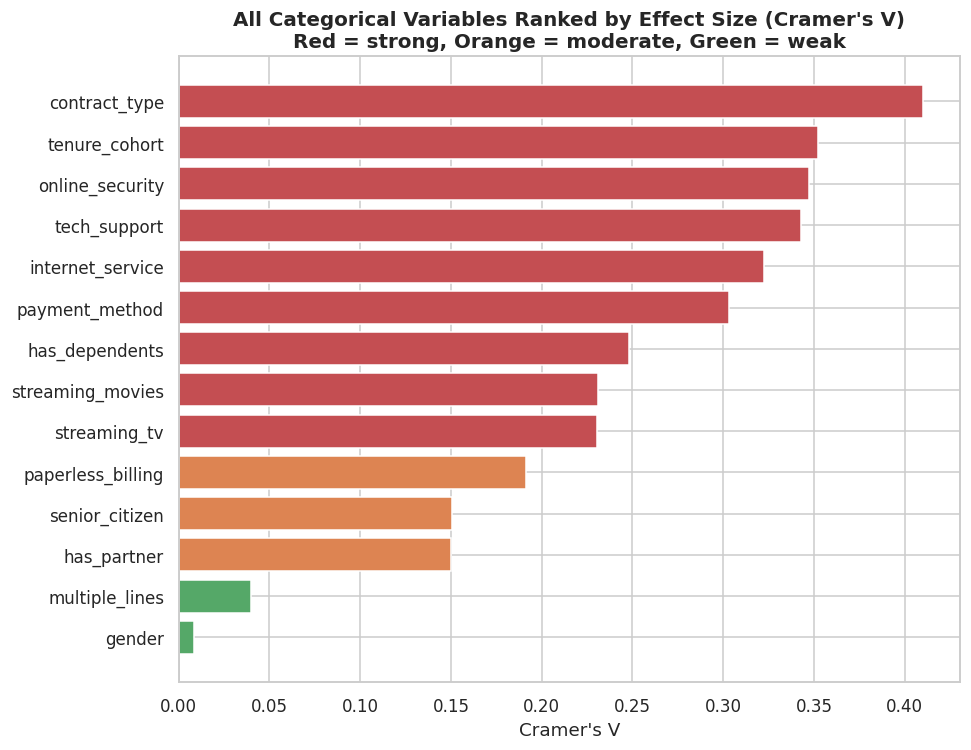

In [35]:
fig, ax = plt.subplots(figsize=(9, 7))
order = categorical_results_df.sort_values("cramers_v")
colors = ["#c44e52" if v >= 0.2 else "#dd8452" if v >= 0.1 else "#55a868" for v in order["cramers_v"]]
ax.barh(order["variable"], order["cramers_v"], color=colors)
ax.set_title("All Categorical Variables Ranked by Effect Size (Cramer's V)\nRed = strong, Orange = moderate, Green = weak")
ax.set_xlabel("Cramer's V")
plt.tight_layout()
fig.savefig(os.path.join(NOTEBOOK_FIG_DIR, "02_all_variables_ranked_by_effect_size.png"))
plt.show()

### Observation

Every single variable tested came back statistically significant at p < 0.05 — with n=7,043, that's
expected and not, by itself, useful for prioritization. The Cramér's V ranking is what actually
separates the drivers worth acting on from the ones that are technically real but practically minor:
`contract_type`, `tenure_cohort`, `internet_service`, `payment_method`, and `online_security`/
`tech_support` cluster at the top; `gender`-adjacent and single-service variables like
`multiple_lines` sit at the bottom.

**Business interpretation:** a retention strategy built on this notebook's findings should prioritize,
in order: (1) contract migration, (2) early-tenure onboarding, (3) fiber-optic service experience and
pricing, (4) payment-method nudges toward autopay, and (5) targeted add-on bundling toward
online_security/tech_support — roughly the order the effect sizes support, not the order the variables
happen to appear in the source dataset.

**Technical interpretation / limitation:** every test in this notebook is univariate — one variable at
a time against churn. Several of these variables are correlated with each other (contract type and
tenure, internet service and monthly charges, payment method and contract type), so their true
*independent* contribution once the others are controlled for can only be estimated with a
multivariate model — exactly what Notebook 3's regression analysis and Notebook 4's feature-importance
analysis are for.

---
## Summary

This notebook reproduced the full analytical engine behind `src/eda/eda_analysis.py` and pushed it
further in three ways: adding Cramér's V effect sizes to every significance test (not just p-values),
finding and fixing a genuine off-by-one bug in `revenue_concentration()`, and tying every finding back
to a concrete business action rather than stopping at "this is significant."

Fourteen analytical steps were completed:

1. Loaded the Notebook 1 output and re-established tenure cohort ordering.
2. Computed headline overview metrics (26.54% churn rate, $139,130.85/month revenue at risk).
3. Confirmed contract type as the single strongest churn driver (42.71% vs. 2.83%, 15x gap).
4. Confirmed tenure cohort as a strong, near-monotonic driver (47.44% down to 6.61%).
5. Found internet service tier is significant, with fiber optic the highest-risk, highest-price tier.
6. Found a non-monotonic, non-obvious pattern in add-on count (1-addon customers churn *more* than
   0-addon customers) and ranked individual service add-ons by effect size.
7. Found payment method (electronic check) as a significant, actionable churn driver.
8. Checked demographics and found gender has no meaningful effect, while household-structure variables
   have real but comparatively small effects.
9. Broke down stated churn reasons among churned customers, corroborating a competitive/service-quality
   story beyond what the behavioral variables alone show.
10. Confirmed IBM's own `churn_score` field is well-calibrated (decile 10 = 100% actual churn), and
    documented why it will be excluded from the Notebook 4 model.
11. Looked at geography and found no meaningful city-level pattern beyond noise, aside from a couple of
    individual cities worth a follow-up look.
12. Built a full correlation matrix, consistent with every segment-level finding above.
13. Built a service-adoption funnel identifying the 1-2-addon-to-3+-addon transition as the highest-
    value upsell target.
14. Quantified revenue concentration (mild, not "whale"-dependent) — after finding and fixing the
    `.loc`/`.iloc` off-by-one bug in the original function.
15. Summarized every statistical test run in this notebook, ranked by effect size, into one
    prioritized view of which drivers actually matter most.

## Key Findings

- Contract type, tenure, and internet service tier are the three strongest churn drivers found —
  each backed by both a significant chi-square test and a large Cramér's V effect size.
- Add-on adoption is non-monotonic at the low end: 1-addon customers are riskier than 0-addon
  customers, a pattern a naive "more add-ons = safer" assumption would completely miss.
- Demographics (beyond household structure) and geography are comparatively weak churn drivers in
  this dataset — real, but not where retention resources should be concentrated first.
- IBM's `churn_score` is genuinely well-calibrated and usable today, which is exactly why it must be
  excluded as a model input later — using it would mean re-deriving a score IBM already provides.
- Revenue is only mildly concentrated by CLTV — no "whale" dependency risk exists in this customer
  base.

## Challenges Faced

- Reproducing every function from `src/eda/eda_analysis.py` inline meant re-typing the exact same
  aggregation logic used to generate `docs/insights_data.json`, while still keeping this notebook
  readable as a standalone document.
- Deciding how deep to go on "improve the analysis" for a phase that's fundamentally descriptive, not
  predictive — Cramér's V was added because p-values alone don't support prioritization at n=7,043, and
  the `.loc`/`.iloc` bug was a genuine, demonstrable error worth fixing rather than an invented one.
- Balancing univariate findings against their own limitations (correlated predictors, small-sample
  geographic noise) without either overstating or dismissing them — several observations explicitly
  flag what a later, multivariate notebook will need to check.

## Decisions Taken

- Kept the fixed `revenue_concentration_FIXED()` as the version of record for this notebook, while
  showing the buggy version side-by-side so the difference (and its real-world negligibility) is
  transparent rather than silently swapped in.
- Chose Cramér's V over odds ratios or other effect-size measures because it works uniformly across
  every categorical variable tested here regardless of the number of categories, keeping the
  variable-ranking comparison in Step 14 apples-to-apples.
- Filtered city-level churn-rate ranking to `customers >= 5` rather than reporting every city, to avoid
  presenting single-digit-sample noise as a real geographic signal.

## Next Step

Notebook 3 moves into formal statistical analysis proper — hypothesis testing beyond the univariate
chi-square/t-tests already run here, ANOVA across multi-level categorical groups, and a multivariate
regression model that can finally separate the individually-significant variables found in this
notebook (contract type, tenure, internet service, payment method) into their independent, controlled
effects on churn.